##### Must do when training a model

- Must optimise your model to find the optimal parameters -> do this either using an optimization method (gradient descent, standard error, etc..) or brute force (GridSearchCV)

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### Import trainingset

In [2]:
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_09_09_variable_trainingset_2.csv')
df = pd.read_csv(x).drop(columns='Unnamed: 0')
df = df.iloc[0::1792, :]

id = df.loc[:, 'condition_id']
X = df.drop(columns=['condition_id', 'condition'])
y = df.loc[:, 'condition']

In [3]:
df

,condition,condition_id,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad,RDX2_min,RDX2_max,category_objet,category_visage,valence_negative,valence_neutre,valence_positive
0,ACP,ACP_10,-44.339866,329.0,-12.022054,1655.0,0.024372,1966.023717,144.529776,1.0,0.0,1.0,0.0,0.0
1792,ACP,ACP_10,-49.265915,300.0,-0.939521,1497.0,0.040373,2427.130388,0.882701,1.0,0.0,0.0,1.0,0.0
3584,ACP,ACP_10,-56.075669,304.0,-16.507952,1492.0,0.033306,3144.480703,272.512489,1.0,0.0,0.0,0.0,1.0
5376,ACP,ACP_10,-83.797519,305.0,-32.862284,1714.0,0.036150,7022.024130,1079.929706,0.0,1.0,1.0,0.0,0.0
7168,ACP,ACP_10,-53.573754,306.0,-15.232583,1011.0,0.054385,2870.147120,232.031592,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786688,DFT,DFT_9,-28.910726,456.0,3.480162,1602.0,0.028264,835.830062,12.111529,1.0,0.0,0.0,1.0,0.0
788480,DFT,DFT_9,-12.990817,227.0,18.032792,905.0,0.045758,168.761314,325.181583,1.0,0.0,0.0,0.0,1.0
790272,DFT,DFT_9,-32.250997,285.0,12.817276,1696.0,0.031941,1040.126798,164.282564,0.0,1.0,1.0,0.0,0.0
792064,DFT,DFT_9,-16.943054,350.0,21.412863,1725.0,0.027895,287.067088,458.510712,0.0,1.0,0.0,1.0,0.0


<Axes: ylabel='condition'>

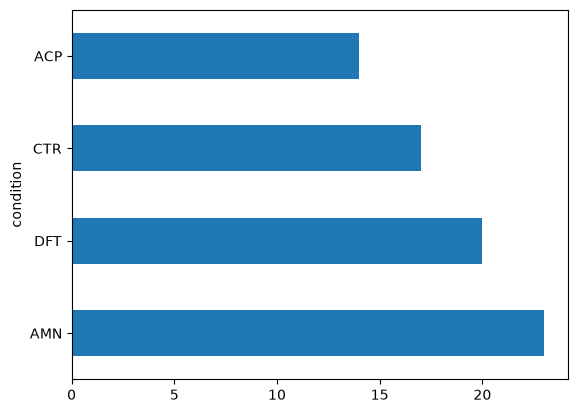

In [4]:
(df.condition.value_counts()/6).plot.barh()

### Train, test, split

In [5]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GroupKFold

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

## Scaling
numeric_features = ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad', 'RDX2_min', 'RDX2_max']
categorical_features = ['category_objet', 'category_visage', 'valence_negative', 'valence_neutre', 'valence_positive']

numeric_transformer = Pipeline([('scaler', RobustScaler())])
categorical_transformer = Pipeline([('passthrough', 'passthrough')])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough', verbose_feature_names_out=False
)

pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ('clf', SVC(random_state=42))
])

param_grid = [
    {
        'clf' : [SVC(random_state=42)],
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__gamma': ['scale', 'auto', 0.0001, 0.001, 0.01],
        'clf__kernel': ['linear', 'rbf']
    },
    {
        'clf' : [RandomForestClassifier(random_state=42)],
        'clf__n_estimators': [1, 10, 50, 100],
        'clf__criterion': ['gini', 'entropy', 'log_loss'],
        'clf__max_depth': [5, 20, 50, 100],
        'clf__min_samples_split': [2, 5, 8, 10]
    }
]

## Store variables
scores = []
params = []
best_estimator = []
results = []
id_prop_train = []
id_prop_test = []

## Optimise model using GridSearchCV
outer_cv = GroupShuffleSplit(n_splits=5, test_size=0.2)
inner_cv = GroupKFold(n_splits=5)

for train_idx, test_idx in outer_cv.split(X, groups=id):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    id_train, id_test = id.iloc[train_idx], id.iloc[test_idx]


    gridsearch = GridSearchCV(pipeline, param_grid, cv=inner_cv)
    gridsearch.fit(X_train, y_train, groups=id_train)

    best_params = gridsearch.best_params_
    best_model = gridsearch.best_estimator_

    score = best_model.score(X_test, y_test)

    scores.append(score)
    params.append(best_params)

    best_estimator.append(gridsearch.best_estimator_)
    results.append(gridsearch.cv_results_)

    id_prop_train.append(y_train.value_counts()/6)
    id_prop_test.append(y_test.value_counts()/6)



In [6]:
print(f'Scores: {scores}\n')

print(id_prop_train)
print(id_prop_test)

print('Params:')
params

Scores: [0.14444444444444443, 0.3, 0.3333333333333333, 0.2, 0.2111111111111111]

[condition
AMN    21.0
DFT    15.0
CTR    14.0
ACP     9.0
Name: count, dtype: float64, condition
AMN    19.0
DFT    17.0
CTR    12.0
ACP    11.0
Name: count, dtype: float64, condition
AMN    18.0
DFT    16.0
CTR    14.0
ACP    11.0
Name: count, dtype: float64, condition
AMN    20.0
DFT    15.0
ACP    13.0
CTR    11.0
Name: count, dtype: float64, condition
AMN    20.0
CTR    14.0
DFT    13.0
ACP    12.0
Name: count, dtype: float64]
[condition
ACP    5.0
DFT    5.0
CTR    3.0
AMN    2.0
Name: count, dtype: float64, condition
CTR    5.0
AMN    4.0
ACP    3.0
DFT    3.0
Name: count, dtype: float64, condition
AMN    5.0
DFT    4.0
ACP    3.0
CTR    3.0
Name: count, dtype: float64, condition
CTR    6.0
DFT    5.0
AMN    3.0
ACP    1.0
Name: count, dtype: float64, condition
DFT    7.0
AMN    3.0
CTR    3.0
ACP    2.0
Name: count, dtype: float64]
Params:


[{'clf': SVC(random_state=42),
  'clf__C': 100,
  'clf__gamma': 0.0001,
  'clf__kernel': 'rbf'},
 {'clf': RandomForestClassifier(random_state=42),
  'clf__criterion': 'entropy',
  'clf__max_depth': 5,
  'clf__min_samples_split': 5,
  'clf__n_estimators': 50},
 {'clf': SVC(random_state=42),
  'clf__C': 0.01,
  'clf__gamma': 'scale',
  'clf__kernel': 'rbf'},
 {'clf': SVC(random_state=42),
  'clf__C': 0.01,
  'clf__gamma': 'scale',
  'clf__kernel': 'rbf'},
 {'clf': SVC(random_state=42),
  'clf__C': 10,
  'clf__gamma': 0.001,
  'clf__kernel': 'rbf'}]

### Make pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC

numeric_features = ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad', 'RDX2_min', 'RDX2_max']

numeric_transformer = Pipeline([
    ('scaler', RobustScaler())
])

ct = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)], 
    remainder='passthrough')

ct.fit_transform(X_train)

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report

pipeline = make_pipeline(RobustScaler(), LogisticRegression(random_state=42))

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

predictions

accuracy = pipeline.score(X_test, y_test)
print ("Accuracy is {}".format(accuracy))

print(classification_report(y_test, predictions))

Accuracy is 0.3111111111111111
              precision    recall  f1-score   support

         ACP       0.00      0.00      0.00        36
         AMN       0.28      0.46      0.35        24
         CTR       0.23      0.50      0.32         6
         DFT       0.37      0.58      0.45        24

    accuracy                           0.31        90
   macro avg       0.22      0.39      0.28        90
weighted avg       0.19      0.31      0.23        90



/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'classifier': [LogisticRegression()],
     'C': np.logspace(-4, 4, 20),
     'l1_ratio': [0, 0.5, 1],
     'solver': ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
     'max_iter': [100, 500, 1000]
     }
]

clf = GridSearchCV(pipeline, param_grid=param_grid)

clf.fit(X_train, y_train)

ValueError: Invalid parameter 'C' for estimator Pipeline(steps=[('robustscaler', RobustScaler()),
                ('logisticregression', LogisticRegression(random_state=42))]). Valid parameters are: ['memory', 'steps', 'transform_input', 'verbose'].

### Apply pipeline

In [10]:
clf.fit(X_train, y_train)
prediction = clf.predict(X_test)
accuracy = clf.score(X_test, y_test)
print(f'{accuracy:.3f}')

0.289


### Optimizing using nested CV

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC

numeric_features = ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad']

numeric_transformer = Pipeline([
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)], 
    remainder='passthrough')


clf = Pipeline([
    ('transform', preprocessor),
    ('svm', SVC())
])

In [33]:
import optuna

from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

def objective(trial):
    classifier_name = trial.suggest_categorical('classifier', ['SVC', 'RandomForest'])
    if classifier_name == 'SVC':
        svc_c = trial.suggest_float('svc_c', 1e-10, 1e10, log=True)
        classifier_obj = SVC(C=svc_c, gamma='auto')
    else:
        rf_max_depth = trial.suggest_int('rf_max_depth', 2, 32, log=True)
        classifier_obj = RandomForestClassifier(max_depth=rf_max_depth, n_estimators=10)

    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print(f'BEST: {study.best_params}')





# svm = SVC()

# p_grid = {"C": [1, 10, 100], "gamma": [0.01, 0.1], "kernel": {'linear', 'poly', 'rbf'}}

# outer_cv = GroupKFold(n_splits=3)
# inner_cv = GroupKFold(n_splits=5)

# scores = []

# for train_idx, test_idx in outer_cv.split(X, y, groups=id):
#     X_train_outer, X_test_outer = X[train_idx], X[test_idx]
#     y_train_outer, y_test_outer = y[train_idx], y[test_idx]

#     clf = GridSearchCV(estimator=svm, param_grid=p_grid, cv=inner_cv)
#     clf.fit(X_train_outer, X_train_outer)
#     scores.append(clf.best_score_)



[I 2026-09-03 19:21:54,100] A new study created in memory with name: no-name-ba5438a9-583c-4301-a983-243161536d01
[I 2026-09-03 19:21:54,102] Trial 0 finished with value: 0.28888888888888886 and parameters: {'classifier': 'SVC', 'svc_c': 1.5348130218959242e-09}. Best is trial 0 with value: 0.28888888888888886.
[I 2026-09-03 19:21:54,102] Trial 1 finished with value: 0.28888888888888886 and parameters: {'classifier': 'RandomForest', 'rf_max_depth': 2}. Best is trial 0 with value: 0.28888888888888886.
[I 2026-09-03 19:21:54,103] Trial 2 finished with value: 0.28888888888888886 and parameters: {'classifier': 'SVC', 'svc_c': 1.2253276580020046e-09}. Best is trial 0 with value: 0.28888888888888886.
[I 2026-09-03 19:21:54,104] Trial 3 finished with value: 0.28888888888888886 and parameters: {'classifier': 'RandomForest', 'rf_max_depth': 8}. Best is trial 0 with value: 0.28888888888888886.
[I 2026-09-03 19:21:54,104] Trial 4 finished with value: 0.28888888888888886 and parameters: {'classifie

BEST: {'classifier': 'SVC', 'svc_c': 1.5348130218959242e-09}


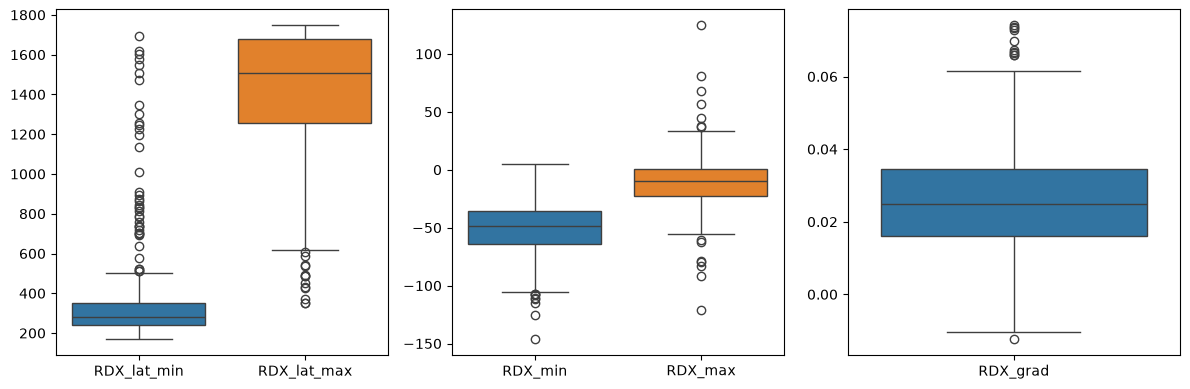

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

sns.boxplot(X.loc[:, ['RDX_lat_min', 'RDX_lat_max', ]], ax=ax[0])
sns.boxplot(X.loc[:, ['RDX_min', 'RDX_max']], ax=ax[1])
sns.boxplot(X.loc[:, ['RDX_grad']], ax=ax[2])

plt.tight_layout()

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


pipeline = make_pipeline(RobustScaler(), RandomForestClassifier(random_state=42))

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.29


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

pipeline = make_pipeline(
    [('scaler', RobustScaler()), ('rf', RandomForestClassifier())],
    [('scaler', RobustScaler()), ('dt', DecisionTreeClassifier())],
    [('scaler', RobustScaler()), ('kn', KNeighborsClassifier())],
    [('scaler', RobustScaler()), ('svc', SVC())],
    [('scaler', RobustScaler()), ('gnb', GaussianNB())]
    )


for pipe in pipeline:
    print(pipe)
    # print(pipe.fit(X_train, y_train).score(X_test, y_test))

[('scaler', RobustScaler()), ('rf', RandomForestClassifier())]
[('scaler', RobustScaler()), ('dt', DecisionTreeClassifier())]
[('scaler', RobustScaler()), ('kn', KNeighborsClassifier())]
[('scaler', RobustScaler()), ('svc', SVC())]
[('scaler', RobustScaler()), ('gnb', GaussianNB())]


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

pipelines = []

pipelines.append(('scaledLR' , (Pipeline([('scaled' , RobustScaler()),('LR' ,LogisticRegression())]))))
pipelines.append(('scaledKNN' , (Pipeline([('scaled' , RobustScaler()),('KNN' ,KNeighborsClassifier())]))))
pipelines.append(('scaledDT' , (Pipeline([('scaled' , RobustScaler()),('DT' ,DecisionTreeClassifier())]))))
pipelines.append(('scaledSVC' , (Pipeline([('scaled' , RobustScaler()),('SVC' ,SVC())]))))
pipelines.append(('scaledMNB' , (Pipeline([('scaled' , RobustScaler()),('MNB' ,GaussianNB())]))))

for pipe, model in pipelines:
    print(pipe, model)

scaledLR Pipeline(steps=[('scaled', RobustScaler()), ('LR', LogisticRegression())])
scaledKNN Pipeline(steps=[('scaled', RobustScaler()), ('KNN', KNeighborsClassifier())])
scaledDT Pipeline(steps=[('scaled', RobustScaler()), ('DT', DecisionTreeClassifier())])
scaledSVC Pipeline(steps=[('scaled', RobustScaler()), ('SVC', SVC())])
scaledMNB Pipeline(steps=[('scaled', RobustScaler()), ('MNB', GaussianNB())])


In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_reg = DecisionTreeClassifier()
tree_reg.fit(X_train, y_train)

predictions = tree_reg.predict(X_test)

#### TEST
- transformer: preprocessing
- estimator: model

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

n_estimators = [10, 50, 100, 200, 300]
max_depth = [5, 25, 50, None]
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]
max_features = ['sqrt', 'log2', None]
bootstrap = [True, False]

param_grid = {
    'rf__n_estimators': n_estimators,
    'rf__max_depth': max_depth,
    'rf__min_samples_split': min_samples_split,
    'rf__min_samples_leaf': min_samples_leaf,
    'rf__max_features': max_features,
    'rf__bootstrap': bootstrap
}

pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in gss.split(X, groups=id):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

NameError: name 'RandomForestClassifier' is not defined

In [101]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold

cv = GroupKFold(n_splits=5)
rf_gridsearch = GridSearchCV(pipeline, param_grid=param_grid, n_jobs=-1, cv=cv)

id_train = id.iloc[train_idx]
rf_gridsearch.fit(X_train, y_train, groups=id_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__bootstrap': [True, False], 'rf__max_depth': [5, 25, ...], 'rf__max_features': ['sqrt', 'log2', ...], 'rf__min_samples_leaf': [1, 2, ...], ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",GroupKFold(n_...shuffle=False)
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versioncha

In [103]:
rf_gridsearch.best_params_

{'rf__bootstrap': True,
 'rf__max_depth': 25,
 'rf__max_features': 'sqrt',
 'rf__min_samples_leaf': 2,
 'rf__min_samples_split': 10,
 'rf__n_estimators': 50}

In [11]:
from sklearn.ensemble import RandomForestClassifier

X_train = ct.set_output(transform="pandas").fit_transform(X_train)
X_test = ct.set_output(transform="pandas").fit_transform(X_test)

base_model = RandomForestClassifier(random_state=42)
base_model.fit(X_train, y_train)
base_model.score(X_test, y_test)

0.2777777777777778

In [105]:
best_model = rf_gridsearch.best_estimator_
best_model.fit(X_train, y_train)
best_model.score(X_test, y_test)

0.2111111111111111

##### Breakdown
- Step 1: test different base models (SVM, RandomForest, LogisticRegression, XGboost) -> use a DummyClassifier as reference to chance
- Step 2: choose the best model and optimise it

Figure out a clear modelling pipeline